# Исследование данных

## Импорт библиотек

In [ ]:
from IPython.display import display, Markdown
from collections import Counter
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns

from rec_sys.utils.display_content import (
    display_common_data_info,
)
from rec_sys.utils.prepare_data import (
    convert_timespamp_to_datetime,
    add_datetime_features,
    get_categories_levels_path,
    get_categories_levels_count,
    get_root_category,
)
from rec_sys.utils.graphs import (
    show_pie,
    show_countplot,
)

pd.set_option('display.max_colwidth', None)
%matplotlib inline

# Путь к папке с данными
DATA_PATH = "../../data"

## Загрузка данных

Описание исходных данных находится в основном файле [01_main.ipynb](./01_main.ipynb).

In [2]:
# Данные о событиях
events_data = pd.read_csv(f"{DATA_PATH}/events.csv")

# Данные о структуре каталога
category_data = pd.read_csv(f"{DATA_PATH}/category_tree.csv")

# Данные о товарах
items_data = pd.concat([
    pd.read_csv(f"{DATA_PATH}/item_properties_part1.csv"),
    pd.read_csv(f"{DATA_PATH}/item_properties_part2.csv")
])

Далее отдельно исследуем данные из каждой таблицы.

## События (`events_data`)

In [3]:
# Посмотрим основную информацию о таблице
display_common_data_info(events_data)

**Первые строки таблицы:**

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


**Размерность таблицы:** (2756101, 5)

**Информация о столбцах:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


None

**Пропуски:**

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

В поле `transactionid` есть пропуски. \
Вероятно, пропуск ставится в том случае, если транзакции не было. \
Позже проверим это.

In [4]:
# Переведем признак timestamp в формат с отображением даты и времени
events_data = convert_timespamp_to_datetime(events_data)

events_data.head()

,visitorid,event,itemid,transactionid,event_datetime
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384
1,829044,view,60987,NaN,2015-05-03 03:00:11.289
2,652699,view,252860,NaN,2015-05-03 03:00:13.048
3,1125936,view,33661,NaN,2015-05-03 03:00:24.154
4,693516,view,297662,NaN,2015-05-03 03:00:26.228


Далее подробнее исследуем каждый признак.

### Тип события (`event`)

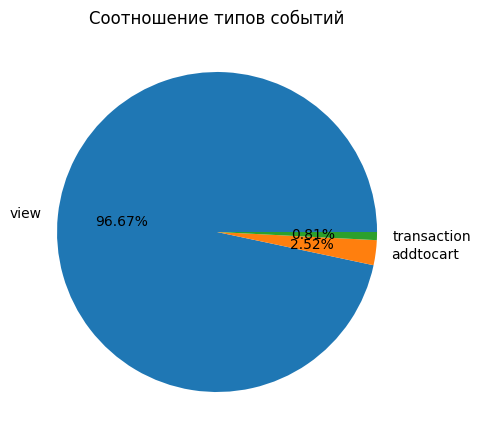

In [5]:
# Посмотрим на соотношение типов событий
show_pie(events_data, "event", "Соотношение типов событий")

Здесь:
- `view` - просмотр
- `addtocart` - добавление в корзину
- `transaction` - транзакция (покупка)

### Транзакции (`transactionid`)

Посмотрим, всегда ли событие  `transaction` в поле `event` соответствует факту проведения транзакции.

In [6]:
# Возьмем только записи с событием транзакции
mask_event_transaction = (events_data["event"] == "transaction")
events_data[mask_event_transaction].head()

,visitorid,event,itemid,transactionid,event_datetime
429,869008,transaction,40685,9765.0,2015-05-03 03:27:21.391
591,345781,transaction,438400,1016.0,2015-05-03 03:35:01.772
1057,586756,transaction,440917,10942.0,2015-05-03 04:01:47.591
1157,435495,transaction,175893,6173.0,2015-05-03 04:07:38.961
1522,266417,transaction,445106,12546.0,2015-05-03 04:31:14.903


Видим, что поле `transactionid` не пустое.

Проверим, есть ли пропуски в поле `transactionid`, при событии `event == transaction`.

In [7]:
mask_null_transaction = events_data["transactionid"].isna()

events_data[mask_event_transaction & mask_null_transaction]

,visitorid,event,itemid,transactionid,event_datetime


Как видим, пропусков нет.

Посмотрим, есть ли заполненный id транзакции при других типах событий.

In [8]:
events_data[~mask_event_transaction & ~mask_null_transaction]

,visitorid,event,itemid,transactionid,event_datetime


Таким образом, при событии `event == transaction` поле `transactionid` всегда заполнено.

In [9]:
print(f"Количество уникальных транзакций: {events_data["transactionid"].nunique()}")

Количество уникальных транзакций: 17672


In [10]:
print(f"Количество записей с транзакциями: {len(events_data[mask_event_transaction])}")

Количество записей с транзакциями: 22457


Таким образом, есть транзакции, на которые приходится несколько покупок.\
Посмотрим на распределение количества покупок по транзакциям.

In [11]:
transactions_volume = events_data\
    .groupby("transactionid")\
    ["itemid"].count()\
    .reset_index()\
    .rename(columns={"itemid": "items_count"})\
    .sort_values("items_count", ascending=False)

transactions_volume

,transactionid,items_count
7063,7063.0,31
765,765.0,28
8351,8351.0,27
2753,2753.0,23
6993,6993.0,21
...,...,...
19,19.0,1
20,20.0,1
21,21.0,1
22,22.0,1


In [12]:
transactions_volume["items_count"].describe()

count    17672.000000
mean         1.270767
std          0.974793
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         31.000000
Name: items_count, dtype: float64

Видим, что максимальное количество товаров в одной транзакции 31.\
Но в большинстве случаев пользователи покупали по 1-му товару.

### Пользователи (`visitorid`)

In [13]:
print(f"Количество уникальных пользователей: {events_data['visitorid'].nunique()}")

Количество уникальных пользователей: 1407580


Посмотрим, со сколькими товарами взаимодействовал каждый пользователь.

In [14]:
visitor_items_volume = events_data.pivot_table(
    index="visitorid",
    values="itemid",
    aggfunc=["count", "nunique"]
).sort_values(by=[("count", "itemid"), ("nunique", "itemid")], ascending=False)

visitor_items_volume

,count,nunique
,itemid,itemid
visitorid,,
1150086,7757,3814
530559,4328,2209
152963,3024,1622
895999,2474,1641
163561,2410,1314
...,...,...
1407575,1,1
1407576,1,1


In [15]:
visitor_items_volume.describe()

,count,nunique
,itemid,itemid
count,1.407580e+06,1.407580e+06
mean,1.958042e+00,1.524019e+00
std,1.258049e+01,7.143724e+00
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,2.000000e+00,1.000000e+00
max,7.757000e+03,3.814000e+03


Видим, что есть пользователи, которые взаимодействовали с тысячами товаров.\
Но большинство с 1-2 товарами.

Посмотрим, как распределяются транзакции по пользователям.

In [16]:
visitor_transactions_volume = events_data[mask_event_transaction].pivot_table(
    index="visitorid",
    values="itemid",
    aggfunc=["count", "nunique"]
).sort_values(by=[("count", "itemid"), ("nunique", "itemid")], ascending=False)

visitor_transactions_volume

,count,nunique
,itemid,itemid
visitorid,,
1150086,559,532
152963,349,319
530559,286,259
684514,189,184
861299,188,183
...,...,...
1406787,1,1
1406981,1,1


In [17]:
visitor_transactions_volume.describe()

,count,nunique
,itemid,itemid
count,11719.000000,11719.000000
mean,1.916290,1.815001
std,8.850529,8.347305
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,559.000000,532.000000


Есть пользователи, которые купили по несколько сотен товаров. \
Но большинство из купивших брали по 1-2 товара.

### Товары (`itemid`)

In [18]:
print(f"Количество уникальных товаров: {events_data['itemid'].nunique()}")

Количество уникальных товаров: 235061


Посмотрим, какие товары чаще покупают.

In [19]:
item_transactions_volume = events_data.pivot_table(
    index="itemid",
    values="transactionid",
    aggfunc="count"
) \
.rename(columns={"transactionid": "transactions_count"}) \
.sort_values("transactions_count", ascending=False)

item_transactions_volume

,transactions_count
itemid,
461686,133
119736,97
213834,92
312728,46
7943,46
...,...
40,0
41,0
12669,0


In [20]:
item_transactions_volume.describe()

,transactions_count
count,235061.000000
mean,0.095537
std,0.738321
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,133.000000


Наибольшее количество покупок для одного товара 133.\
Но большинство товаров не покупают.

### Время события (`event_datetime`)

In [21]:
min_date = str(events_data['event_datetime'].min().date())
max_date = str(events_data['event_datetime'].max().date())

print(f"Данные представлены за период с {min_date} по {max_date}.")

Данные представлены за период с 2015-05-03 по 2015-09-18.


In [22]:
# Добавим в таблицу признаки даты  и времени
events_data = add_datetime_features(events_data)

events_data.head()

,visitorid,event,itemid,transactionid,event_datetime,date,month,day,day_of_week,hour
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384,2015-05-03,5,3,6,3
1,829044,view,60987,NaN,2015-05-03 03:00:11.289,2015-05-03,5,3,6,3
2,652699,view,252860,NaN,2015-05-03 03:00:13.048,2015-05-03,5,3,6,3
3,1125936,view,33661,NaN,2015-05-03 03:00:24.154,2015-05-03,5,3,6,3
4,693516,view,297662,NaN,2015-05-03 03:00:26.228,2015-05-03,5,3,6,3


Посмотрим, какое количество продаж было каждый день.

In [23]:
# Флаг наличия транзакции, далее суммируем это значение за каждый день
events_data["is_transaction"] = events_data["event"] == "transaction"

transactions_time_series = events_data.pivot_table(
    index="date",
    values="is_transaction",
    aggfunc="sum",
).rename(columns={"is_transaction": "transactions_count"})

transactions_time_series

,transactions_count
date,
2015-05-03,83
2015-05-04,154
2015-05-05,225
2015-05-06,258
2015-05-07,217
...,...
2015-09-14,154
2015-09-15,158
2015-09-16,137


In [24]:
transactions_time_series.describe()

,transactions_count
count,139.000000
mean,161.561151
std,58.246368
min,15.000000
25%,112.500000
50%,162.000000
75%,207.500000
max,276.000000


Отобразим временной ряд на графике.

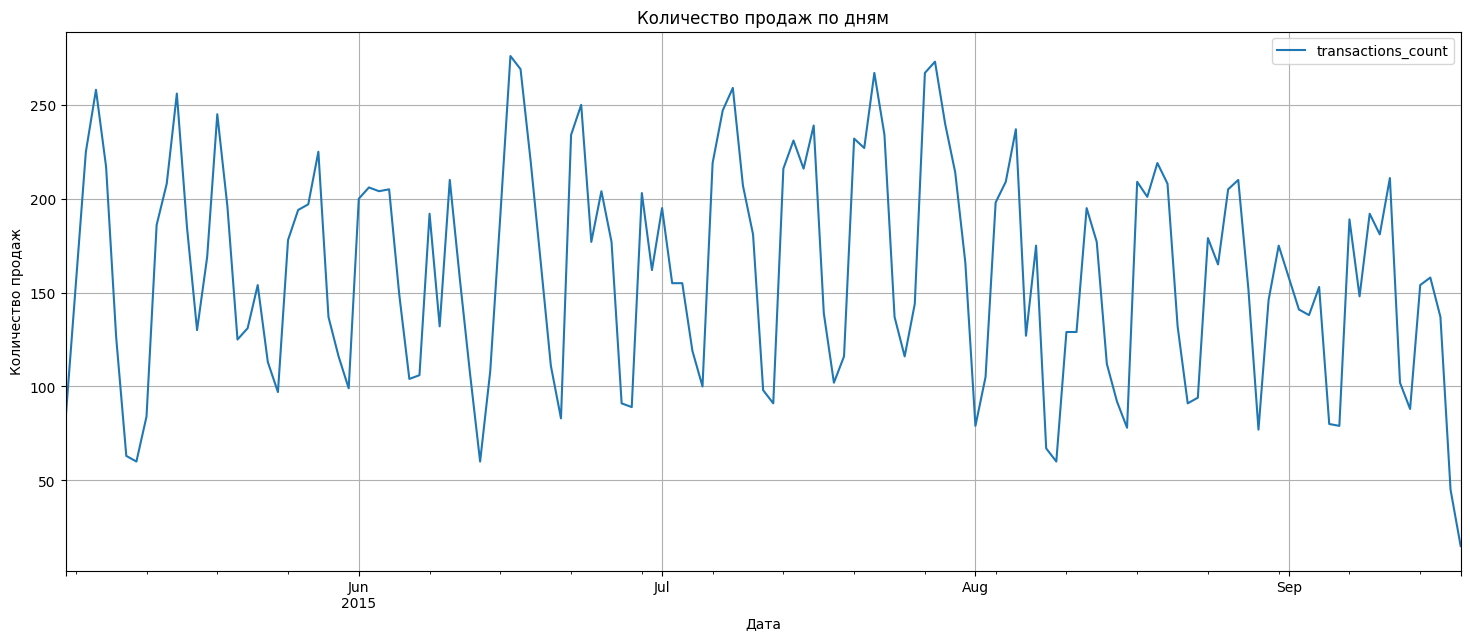

In [25]:
transactions_time_series.plot(
    figsize=(18, 7),    
    title="Количество продаж по дням",
    xlabel="Дата",
    ylabel="Количество продаж",
    grid=True,
);

На первый взгляд можно сказать, что явного тренда не наблюдается.\
Возможно, есть недельная сезонность, но нужно посмотреть график поближе.

Возьмем данные за месяц.

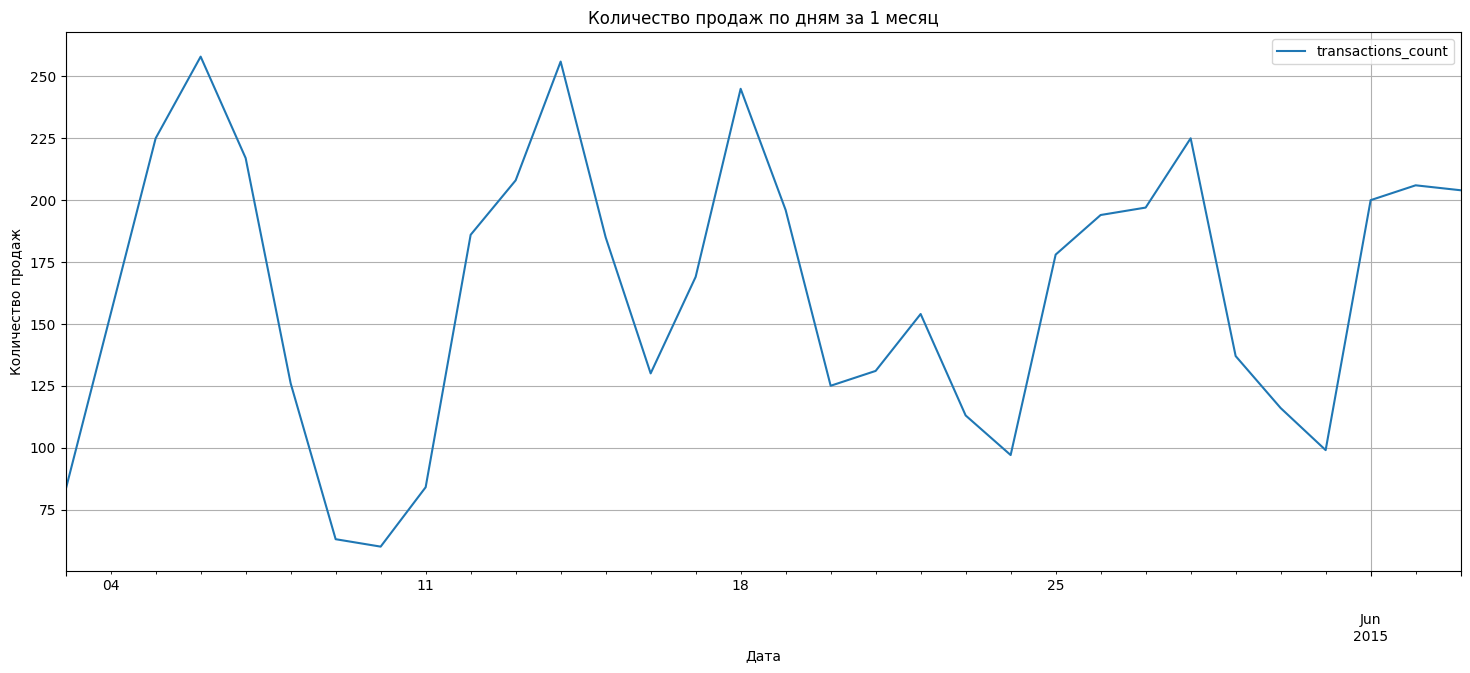

In [26]:
mask_month = transactions_time_series.index <= "2015-06-03"

transactions_time_series[mask_month].plot(
    figsize=(18, 7),    
    title="Количество продаж по дням за 1 месяц",
    xlabel="Дата",
    ylabel="Количество продаж",
    grid=True,
);

На недельную сезонность это не похоже.\
Попробуем разложить ряд.

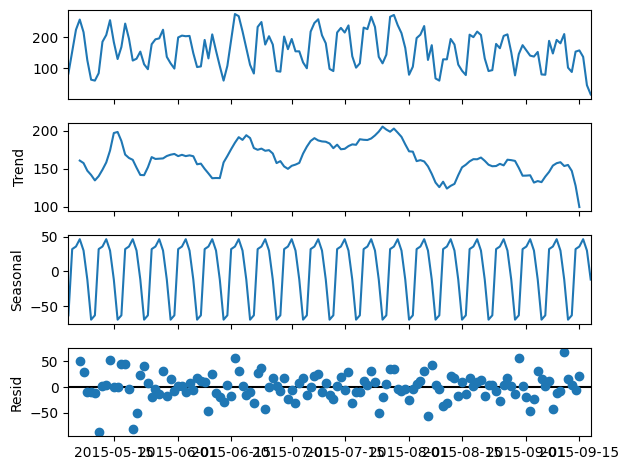

In [27]:
# Производим декомпозицию временного ряда 
decomposition = seasonal_decompose(transactions_time_series)
fig = decomposition.plot()
plt.show()

Алгоритм выделил сезонность, но учитывая вид тренда, с которым она складывается, \
можно сказать, что явных закономерностей в этом ряде не наблюдается.

Далее посмотрим, как действия пользователей распределяется по месяцам, дням и времени дня.

#### Распределение количества действий пользователей по месяцам

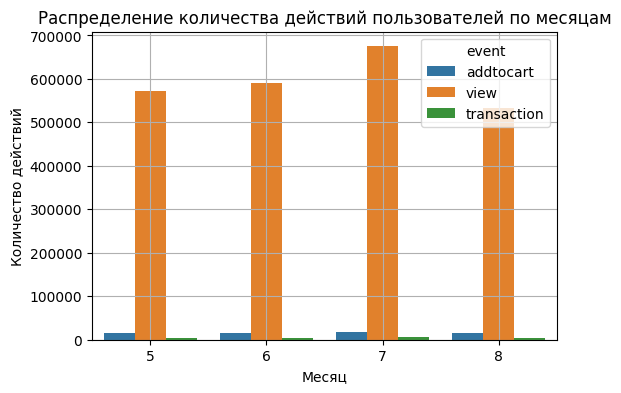

In [28]:
# Исключим из данных сентябрь, т.к. у нас данные только до 18 числа
mask_exclude_september = events_data["month"] < 9

show_countplot(
    events_data[mask_exclude_september],
    "month",
    title="Распределение количества действий пользователей по месяцам",
    xlabel="Месяц",
    ylabel="Количество действий",
    hue_feature_name="event",
)

Соотношение действий просмотр/добавление в корзину/покупка для каждого месяца\
примерно такое же , как на всем датасете.\
Чтобы увидеть различия по продажам, построим график для них отдельно.

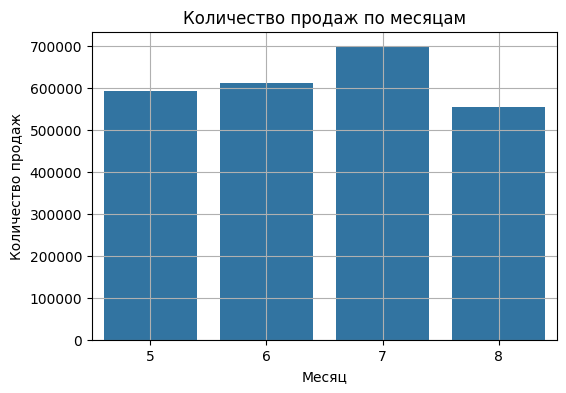

In [29]:
show_countplot(
    events_data[mask_exclude_september],
    "month",
    title="Количество продаж по месяцам",
    xlabel="Месяц",
    ylabel="Количество продаж",
)

Наибольшее количество продаж просмотров (и продаж) было в июле. \
И общее количество действий распределено по месяцам примерно одинаково.

#### Распределение количества действий пользователей по числам месяца

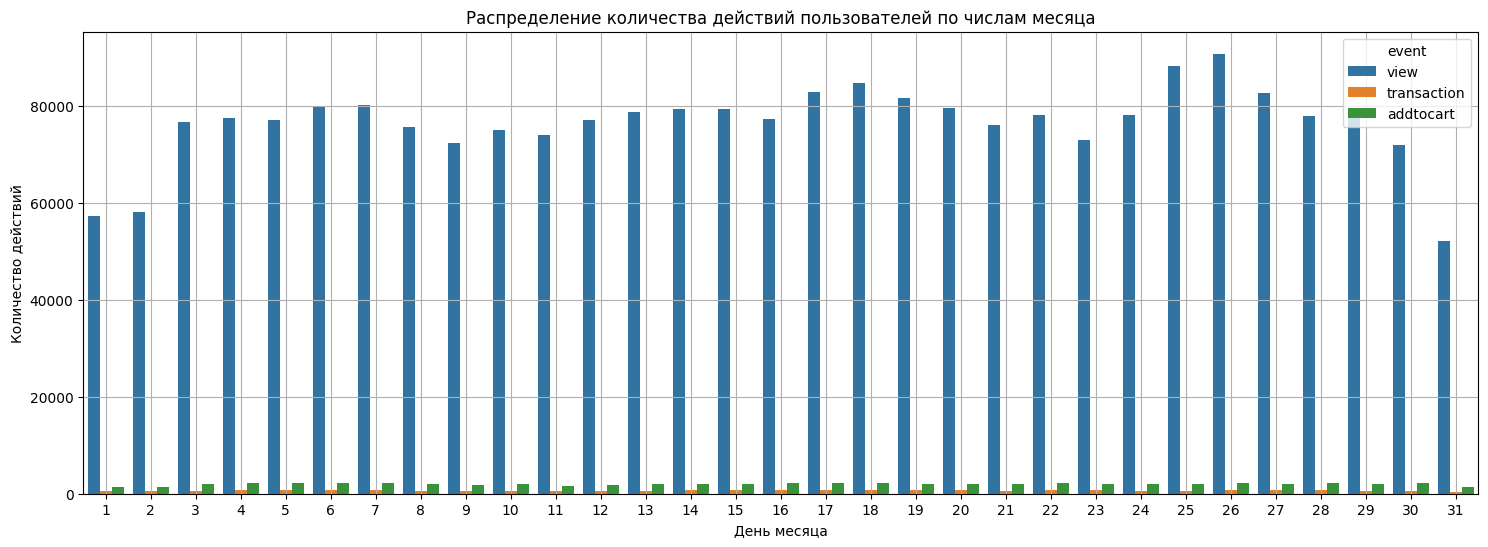

In [30]:
show_countplot(
    # Так же исключим сентябрь, т.к. за него не полные данные
    events_data[mask_exclude_september],
    "day",
    title="Распределение количества действий пользователей по числам месяца",
    xlabel="День месяца",
    ylabel="Количество действий",
    figsize=(18, 6),
    hue_feature_name="event",
)

Здесь также соотношение действий просмотр/добавление в корзину/покупка по дням\
примерно такое же, как на всем датасете.\
31 число есть не в каждом месяце, поэтому в эту дату покупок посчиталось меньше.\
Чтобы увидеть изменения по покупкам, построим по ним график отдельно.

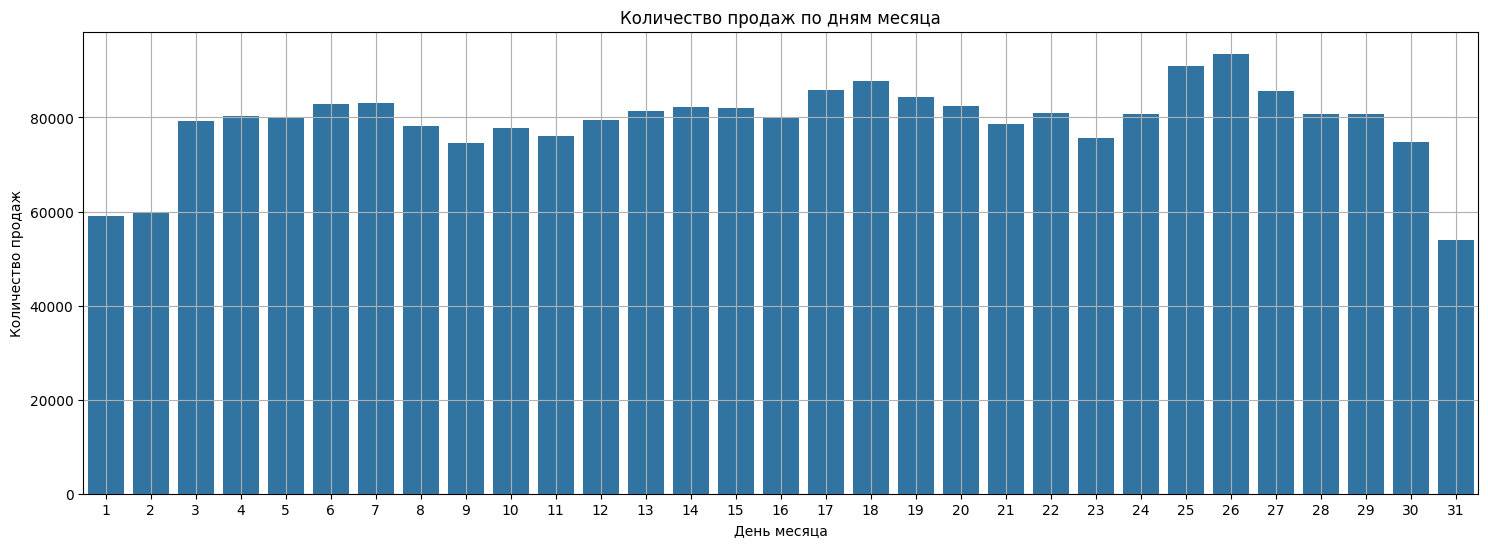

In [31]:
show_countplot(
    events_data[mask_exclude_september],
    "day",
    title="Количество продаж по дням месяца",
    xlabel="День месяца",
    ylabel="Количество продаж",
    figsize=(18, 6),
)

Распределение по покупкам примерно соответствует количеству просмотров.\
Видно, что количество просмотров и продаж меньше 1 и 2 числа месяца,\
и больше 26 и 27 числа.

#### Распределение количества действий пользователей по дням недели

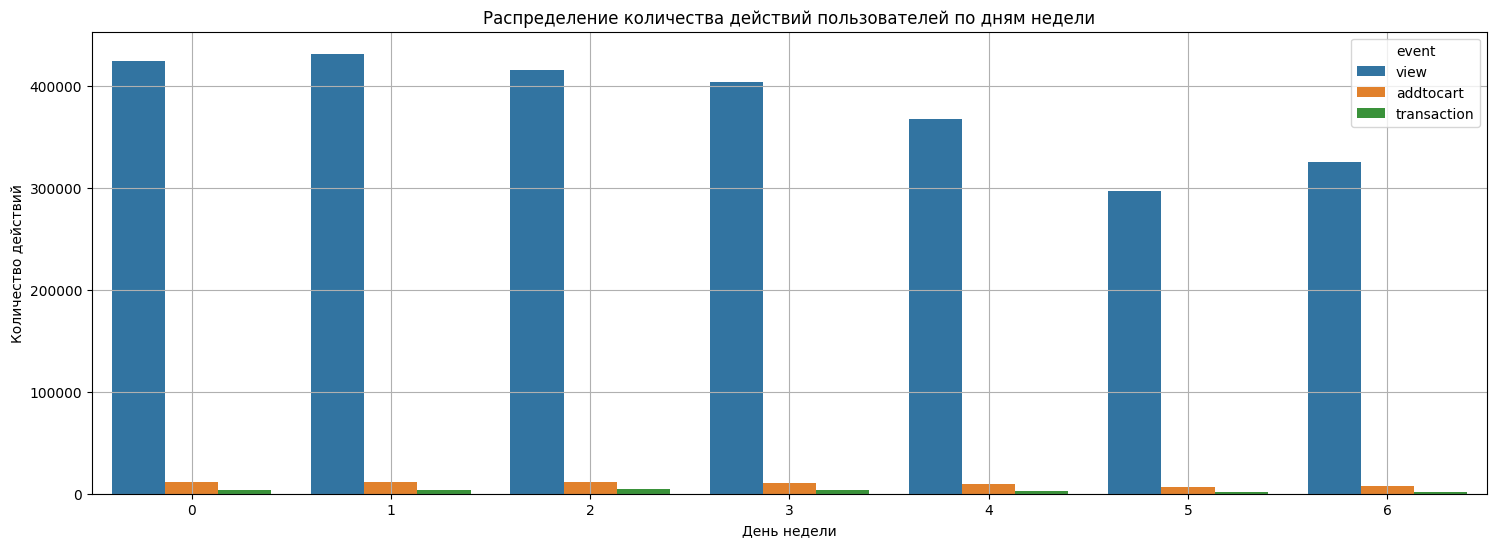

In [32]:
show_countplot(
    events_data,
    "day_of_week",
    title="Распределение количества действий пользователей по дням недели",
    xlabel="День недели",
    ylabel="Количество действий",
    figsize=(18, 6),
    hue_feature_name="event",
)

Здесь обозначения дней недели:
- 0 - понедельник
- 6 - воскресенье

Наибольшая активность в начале недели. И она спадает к выходным.\
Посмотрим отдельно график по покупкам.

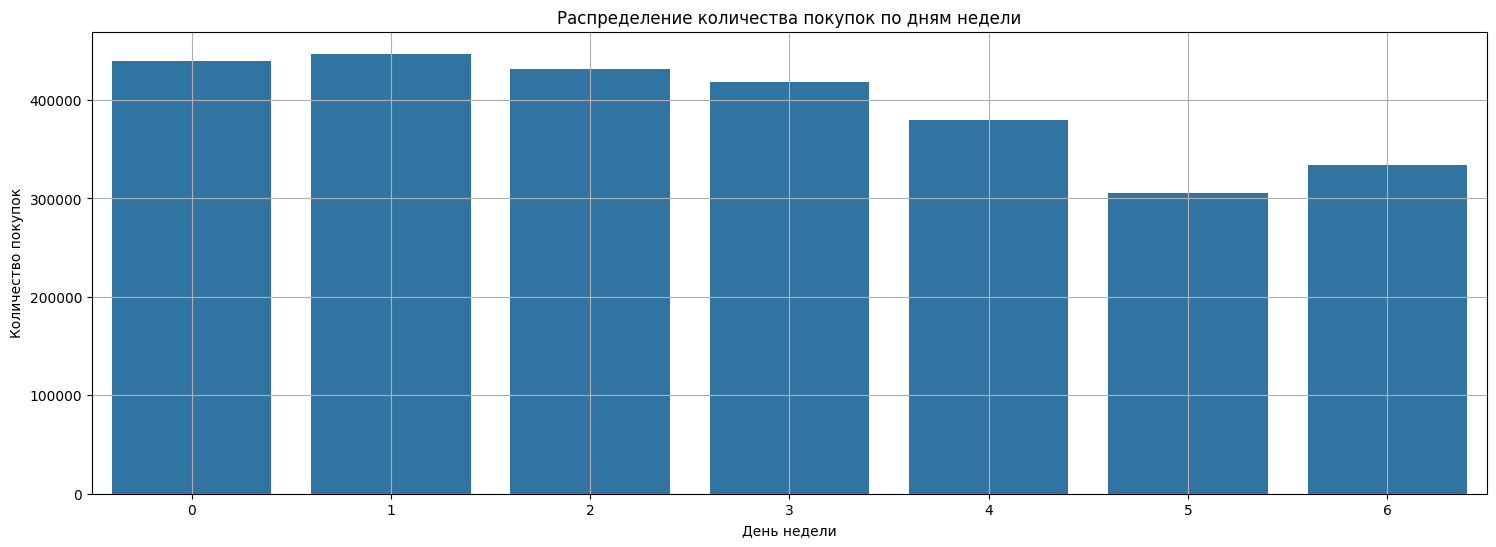

In [33]:
show_countplot(
    events_data,
    "day_of_week",
    title="Распределение количества покупок по дням недели",
    xlabel="День недели",
    ylabel="Количество покупок",
    figsize=(18, 6),
)

Видно, что количество покупок по дням недели примерно пропорционально количеству просмотров.\
И так же количество больше в начале недели и спадает к выходным.

#### Распределение количества действий пользователей по времени дня

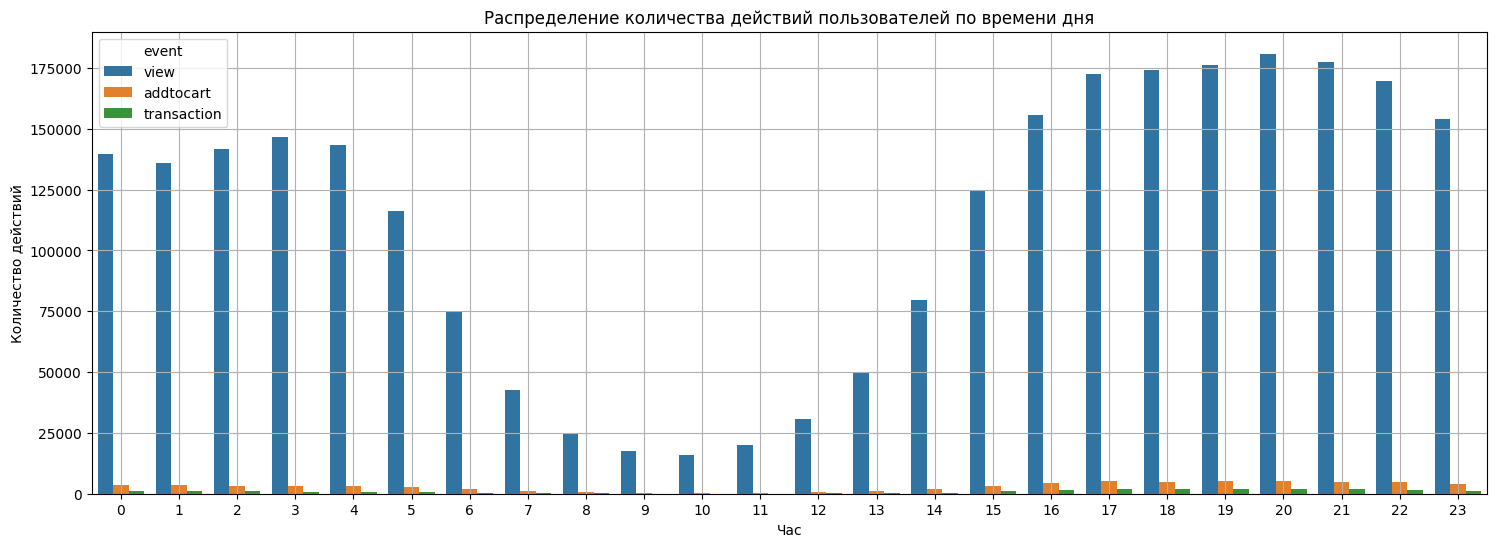

In [34]:
show_countplot(
    events_data,
    "hour",
    title="Распределение количества действий пользователей по времени дня",
    xlabel="Час",
    ylabel="Количество действий",
    figsize=(18, 6),
    hue_feature_name="event",
)

С 6  до 14 часов активность пользователей более низкая.\
Посмотрим отдельно, как по времени дня распределяются транзакции.

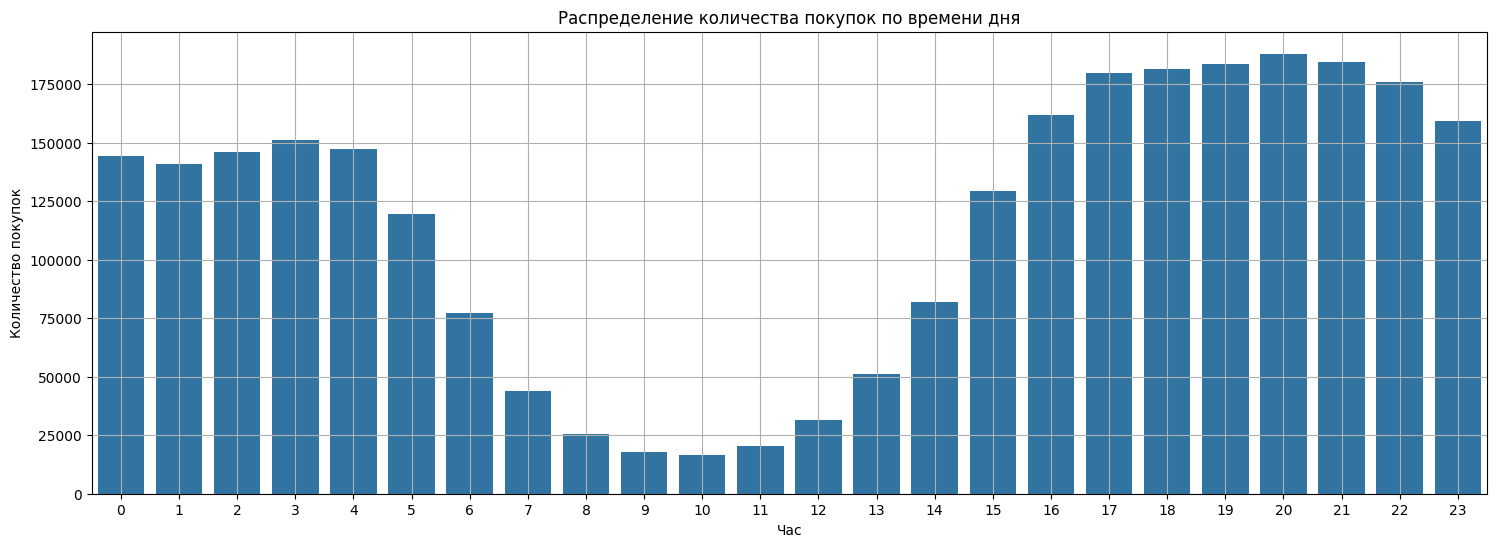

In [35]:
show_countplot(
    events_data,
    "hour",
    title="Распределение количества покупок по времени дня",
    xlabel="Час",
    ylabel="Количество покупок",
    figsize=(18, 6),
)

Видно ту же тенденцию, что и для просмотров.\
С 6 до 14 часов активность пользователей ниже.

#### Распределение транзакций по дням недели и времени дня

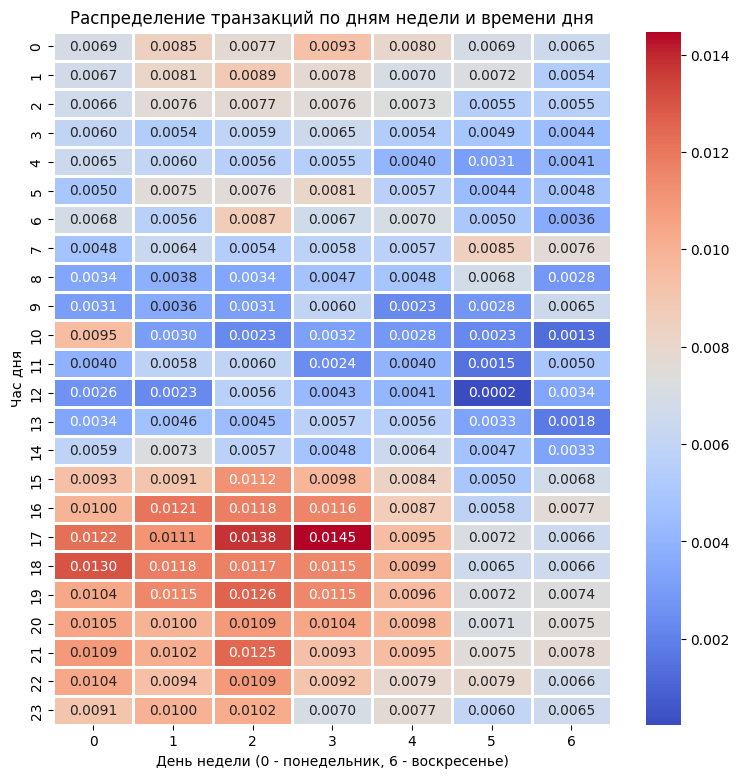

In [36]:
transactions_in_days_and_hours = events_data.pivot_table(
    index="hour",
    columns="day_of_week",
    values="is_transaction",
    aggfunc="mean"
)

min_transactions = transactions_in_days_and_hours.min().min()
max_transactions = transactions_in_days_and_hours.max().max()

# Фигура и координатная плоскость
fig, axes = plt.subplots(figsize=(9, 9))

# Параметры тепловой карты
sns.heatmap(
    transactions_in_days_and_hours, 
    annot=True, 
    vmin=min_transactions, 
    vmax=max_transactions, 
    center=(min_transactions + max_transactions) / 2, 
    linewidths=.9, 
    ax=axes, 
    fmt=".4f", 
    cmap="coolwarm",
)
plt.title("Распределение транзакций по дням недели и времени дня")
plt.xlabel("День недели (0 - понедельник, 6 - воскресенье)")
plt.ylabel("Час дня")

# Выведем график
plt.show()

В среднем наибольшее количество покупок приходилось на первую половину недели с 15 до 23 часов.

### Популярность товаров по месяцам

Посмотрим, меняются ли популярные товары в зависимости от месяца или они постоянны.

In [37]:
def get_popular_items_data(month: int) -> pd.DataFrame:
    mask_month = events_data["month"] == month
    
    popular_items_data = events_data[mask_month].pivot_table(
        index="itemid",
        values="is_transaction",
        aggfunc="sum",
    ) \
    .rename(columns={"is_transaction": "transactions_count"}) \
    .sort_values("transactions_count", ascending=False) \
    .head(5)
    
    return popular_items_data


In [38]:
popular_items = []

for month in events_data["month"].unique():
    popular_items_data = get_popular_items_data(month)
    popular_items = popular_items + list(popular_items_data.index)
    display(Markdown(f"**5 самых популярных товаров за {month}-й месяц**"))
    display(popular_items_data)

**5 самых популярных товаров за 5-й месяц**

,transactions_count
itemid,
369447,31
7943,17
318333,17
379520,14
51354,11


**5 самых популярных товаров за 6-й месяц**

,transactions_count
itemid,
119736,25
382885,18
461686,17
48030,16
312728,14


**5 самых популярных товаров за 7-й месяц**

,transactions_count
itemid,
213834,51
461686,40
445351,39
119736,28
48030,21


**5 самых популярных товаров за 8-й месяц**

,transactions_count
itemid,
461686,46
119736,27
248455,26
546,17
334401,17


**5 самых популярных товаров за 9-й месяц**

,transactions_count
itemid,
213834,25
461686,24
312728,12
334401,11
153778,8


Видим, что некоторые товары повторяются, но картина каждый месяц разная.\
Посмотрим, какие товары повторяются чаще других.

In [39]:
Counter(popular_items)

Counter({461686: 4,
         119736: 3,
         48030: 2,
         312728: 2,
         213834: 2,
         334401: 2,
         369447: 1,
         7943: 1,
         318333: 1,
         379520: 1,
         51354: 1,
         382885: 1,
         445351: 1,
         248455: 1,
         546: 1,
         153778: 1})

Чаще других повторяется товар 461686.\
И он же лидер по количеству продаж, как мы выяснили ранее.

## Дерево категорий (`category_data`)

In [40]:
# Посмотрим основную информацию о таблице
display_common_data_info(category_data)

**Первые строки таблицы:**

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


**Размерность таблицы:** (1669, 2)

**Информация о столбцах:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


None

**Пропуски:**

categoryid     0
parentid      25
dtype: int64

Пропуски в столбце `parentid` видимо, у тех категорий, которые являются родительскими для всех.

In [41]:
print(f"Количество уникальных категорий: {category_data["categoryid"].nunique()}")

Количество уникальных категорий: 1669


In [43]:
# Сформируем признак в виде цепочки категорий (от корневой до текущей)
category_data["levels_path"] = category_data["categoryid"].apply(
    lambda categoryid: get_categories_levels_path(category_data, categoryid)
)

# Добавим признак с количеством уровней категорий в цепочке
category_data["levels_count"] = category_data["levels_path"].apply(get_categories_levels_count)

# Извлечем также корневую категорию
category_data["root_categoryid"] = category_data["levels_path"].apply(get_root_category)

category_data.head()

,categoryid,parentid,levels_path,levels_count,root_categoryid
0,1016,213.0,1532 -> 1299 -> 213 -> 1016,4,1532
1,809,169.0,395 -> 1257 -> 169 -> 809,4,395
2,570,9.0,653 -> 351 -> 9 -> 570,4,653
3,1691,885.0,1579 -> 885 -> 1691,3,1579
4,536,1691.0,1579 -> 885 -> 1691 -> 536,4,1579


In [44]:
print(f"Максимальная глубина каталога: {category_data['levels_count'].max()}")

Максимальная глубина каталога: 6


In [45]:
print(f"Количество корневых категорий: {category_data['root_categoryid'].nunique()}")

Количество корневых категорий: 25


Посмотрим на количество подкатегрий в каждой корневой категории.

In [48]:
category_data.pivot_table(
    index="root_categoryid",
    values="categoryid",
    aggfunc="count"
) \
.rename(columns={"categoryid": "categories_count"}) \
.sort_values("categories_count")

,categories_count
root_categoryid,
231,1
1182,4
859,4
659,5
1692,9
1057,10
1452,10
803,14
1394,16


Максимальное количество вложенных категорий (включая корневую) 290 штук.

## Товары (`items_data`)

In [ ]:
# Посмотрим основную информацию о таблице
display_common_data_info(items_data)

**Первые строки таблицы:**

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


**Размерность таблицы:** (20275902, 4)

**Информация о столбцах:**

<class 'pandas.core.frame.DataFrame'>
Index: 20275902 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 773.5+ MB


None

**Пропуски:**

timestamp    0
itemid       0
property     0
value        0
dtype: int64

In [ ]:
# Переведем признак timestamp в формат с отображением даты и времени
items_data = convert_timespamp_to_datetime(items_data)

items_data.head()

,itemid,property,value,event_datetime
0,317951,790,n32880.000,2015-05-10 03:00:00
1,422842,480,1133979,2015-05-10 03:00:00
2,310185,776,103591,2015-05-10 03:00:00
3,110973,112,679677,2015-05-10 03:00:00
4,179597,available,0,2015-05-10 03:00:00
